In [29]:
import json
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, AutoTokenizer, get_scheduler
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
from tqdm.notebook import tqdm, trange
from time import perf_counter
from PIL import Image
import pandas as pd
from PIL import Image
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
# run data loader to unzip images

In [64]:
# set random seeds for repeatability
import numpy as np
import random

def set_seed(seed_val):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

In [65]:
seed_val = 42
set_seed(seed_val)

In [81]:
# original file: 2024-08-15_curr_df.pkl; same exact data frame as manual_classification_cl6.pkl

# load manually classified data with image dir using Images1, Images2, Images3 folders
with open("data/manual_classification_cl6_updated_image_dir.pkl", 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()

print("shape:", feats_df.shape)
feats_df.head()

shape: (7307, 5)


,class,noise,path,seed,dir
0,3,4,noise 4 20604.0.png,20604.0,content/Images1/
1,3,6,noise 6 20289.0.png,20289.0,content/Images1/
2,4,23782.0,noise 6 23782.0.png,23782.0,content/Images2/
3,2,2,7761.png,7761,content/Images3/
4,1,2,8366.png,8366,content/Images3/


In [82]:
counter = 0
for i in feats_df["class"]:
  try:
    a = int(i)

  except:
    print(counter) # rows with non-integer class labels

  counter += 1

700
1159
4061


In [83]:
feats_df = feats_df.drop([700,1159,4061], axis = "rows") # dr
feats_df.reset_index(inplace = True, drop = True)

In [84]:
feats_df["class"] = feats_df["class"].astype(int)

In [85]:
clusters = np.unique(np.array(feats_df["class"].astype(int))) # list of unique clusters
print(np.unique(np.array(feats_df["class"].astype(int)), return_counts = True)) 

cluster_dfs = [] # list of dfs for each cluster

for i in clusters:
  df = feats_df[feats_df["class"] == i]
  df.reset_index(inplace = True, drop = True)
  cluster_dfs.append(df)

# print sizes of each class
class_num1 = 0
for df in cluster_dfs:
  print(str(class_num1) + ": " + str(df.shape[0]))
  class_num1 += 1

(array([1, 2, 3, 4, 5, 6, 7]), array([1993, 2329, 2330,  122,  330,  165,   35]))
0: 1993
1: 2329
2: 2330
3: 122
4: 330
5: 165
6: 35


In [86]:
feats_df["class"] = np.array(feats_df["class"].astype(int) -1).astype(int)

In [87]:
# be careful, rerunning this cell will reassign class labels minus 1 again unless you reload the dataframe

# print the number of images in each class
print(np.unique(np.array(feats_df["class"]), return_counts = True)) 

(array([0, 1, 2, 3, 4, 5, 6]), array([1993, 2329, 2330,  122,  330,  165,   35]))


In [88]:
# change size of sampling data

df_train = feats_df.sample(frac = 0.08, random_state = 42)
df_train.reset_index(inplace = True, drop = True)
df_val_test = feats_df.drop(df_train.index)

p_out = 0.25

df_val_test = df_val_test.sample(frac = p_out, random_state = 42)
df_val = df_val_test.sample(frac = 0.5, random_state = 42)
df_test = df_val_test.drop(df_val.index)

df_val.reset_index(inplace = True, drop = True)
df_test.reset_index(inplace = True, drop = True)

In [89]:

print(df_train.shape)
print(df_val.shape)
print(df_test.shape)

(584, 5)
(840, 5)
(840, 5)


In [90]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
# TRAINING SETTINGS
NUM_EPOCHS = 20


# LEARNING RATE SETTINGS
BASE_LR = 1e-5
DECAY_WEIGHT = 0.1 # factor by which the learning rate is reduced.
EPOCH_DECAY = 15 # number of epochs after which the learning rate is decayed exponentially by DECAY_WEIGHT.


# # DATASET INFO
# NUM_CLASSES = 2 # set the number of classes in your dataset
# # DATA_DIR = 'hymenoptera_data/' # to run with the sample dataset, just set to 'hymenoptera_data'


# DATALOADER PROPERTIES
BATCH_SIZE = 64


# GPU SETTINGS
CUDA_DEVICE = 0 # Enter device ID of your gpu if you want to run on gpu. Otherwise neglect.
GPU_MODE = 0 # set to 1 if want to run on gpu.


# # SETTINGS FOR DISPLAYING ON TENSORBOARD
# USE_TENSORBOARD = 0 #if you want to use tensorboard set this to 1.
# TENSORBOARD_SERVER = "YOUR TENSORBOARD SERVER ADDRESS HERE" # If you set.
# EXP_NAME = "Nathan_Car" # if using tensorboard, enter name of experiment you want it to be displayed as.


use_gpu = GPU_MODE
if use_gpu:
    torch.cuda.set_device(CUDA_DEVICE)
# show transforms and dataset loader, from https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [91]:
def data_transforms(image, mode):
  if mode == "train":
    tnsfrm = transforms.Compose([
            # transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor()
        ])
  elif mode == "val":
    tnsfrm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224,224))
    ])

  img = tnsfrm(image)
  img = torch.cat((img,img,img),0)
  return img


class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, transform, mode, target_transform):
      # image dir and file_name
        self.img_dir = annotations_file["dir"]
        self.path = annotations_file["path"]
      # gets the labels from the dataframe provided in the dataloader
        self.img_labels = annotations_file["class"]
      #transform is defined previously
        self.transform = transform
      #no target transforms for this task
        self.target_transform = target_transform
      # training mode
        self.mode = mode

    def __len__(self):
      #gives the size of whatever dataset is being loaded
        return len(self.img_labels)

    def __getitem__(self, idx):
      #get the path to the image
        img_path = self.img_dir[idx] + self.path[idx]
        #loads in the image
        image = Image.open(img_path)
        #gets the corresponding label
        label = self.img_labels.iloc[idx]
        label_list = np.zeros(7)
        label_list[label - 1] = 1
        #does the transforms
        if self.transform:
            image = self.transform(image,self.mode)
        if self.target_transform:
            label = self.target_transform(label)
            
        #returns the transformed image and its label
        return image.to(torch.float32), torch.tensor(label)

dsets = {}
dsets["train"] = CustomImageDataset(df_train, data_transforms, "train", None)
dsets["val"] = CustomImageDataset(df_val, data_transforms, "val", None)

train_dataloader = DataLoader(dsets["train"], batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dsets["val"], batch_size=BATCH_SIZE, shuffle=True)

dset_loaders = {"train":train_dataloader, "val":val_dataloader}

dset_sizes = {}
dset_sizes['train'] = df_train.shape[0]
dset_sizes['val'] = df_val.shape[0]

print(dset_sizes)

{'train': 584, 'val': 840}


In [94]:
import time
from torch.autograd import Variable
import copy
def train_model(model, criterion, optimizer, lr_scheduler, num_epochs):
    since = time.time()

    best_model = model
    best_loss = float('inf')

    losses = {'train': [], 'val': []}

    # uncomment all accuracies lines to also return accuracies
    # accuracies = {'train': [], 'val': []}
    
    for epoch in range(num_epochs):
        print('-' * 10)
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                optimizer = lr_scheduler(optimizer, epoch)
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to eval mode for validation (no need to track gradients)

            running_loss = 0.0
            # running_corrects = 0

            counter=0
            # Iterate over data, getting one batch of inputs (images) and labels each time.
            for data in dset_loaders[phase]:
                inputs, labels = data

                if use_gpu:
                    try:
                        inputs, labels = Variable(inputs.float().cuda()), Variable(labels.long().cuda())
                    except Exception as e:
                        print("ERROR! here are the inputs and labels before we print the full stack trace:")
                        print(inputs, labels)
                        raise e
                else:
                    inputs, labels = Variable(inputs), Variable(labels)

                # Set gradient to zero to delete history of computations in previous epoch. Track operations so that differentiation can be done automatically.
                optimizer.zero_grad()
                outputs = model(inputs)

                # _, preds = torch.max(outputs, 1) # for accuracies
                # preds = preds.to(torch.float32) # for accuracies
                
                loss = criterion(outputs, labels).to(torch.float32)

                # Print a line every 10 batches so you have something to watch and don't feel like the program isn't running.
                if counter%10==0:
                    print("Reached batch iteration", counter)

                counter+=1

                # backward + optimize only if in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
                try:
                    running_loss += loss.item()
                    #running_corrects += torch.sum(preds == labels.data)
                except:
                    print('unexpected error, could not calculate loss or do a sum.')

            epoch_loss = running_loss / dset_sizes[phase]
            # epoch_acc = running_corrects.item() / float(dset_sizes[phase])
            
            print('Epoch' + str(epoch) + "loss = " + str(epoch_loss))
            # accuracies[phase].append(epoch_acc)
            losses[phase].append(epoch_loss)

            # deep copy the model
            if phase == 'val':
                # tensorboard - visualize training process in real-time
                # if USE_TENSORBOARD:
                #     foo.add_scalar_value('epoch_loss', epoch_loss,step=epoch)
                #     foo.add_scalar_value('epoch_acc', epoch_acc,step=epoch)
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model = copy.deepcopy(model)
                    print('new best loss =', best_loss)
    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best loss: {:4f}'.format(best_loss))
    print('returning and looping back')

    return best_model, losses # return accuracies as well if needed


# This function changes the learning rate as the model trains.
def exp_lr_scheduler(optimizer, epoch, init_lr=BASE_LR, lr_decay_epoch=EPOCH_DECAY):
    """Decay learning rate by a factor of DECAY_WEIGHT every lr_decay_epoch epochs."""
    lr = init_lr * (DECAY_WEIGHT**(epoch // lr_decay_epoch))

    if epoch % lr_decay_epoch == 0:
        print('LR is set to {}'.format(lr))

    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    return optimizer




#start with resnet50
model_ft = models.resnet50(pretrained=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 7)

#set loss function to binary crossentropy
criterion = nn.CrossEntropyLoss()

if use_gpu:
    criterion.cuda()
    model_ft.cuda()

optimizer_ft = optim.AdamW(model_ft.parameters(), lr=0.0001)


# Run the functions and save the best model in the function model_ft.
model_ft, losses = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

# to also print accuracies by epoch
# model_ft, losses, accuracies = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

for split in ['train', 'val']:
    # print(split, "accuracies by epoch:", accuracies[split])
    print(split, "losses by epoch:", losses[split])

----------
Epoch 0/19
----------
LR is set to 1e-05
Reached batch iteration 0
Epoch0loss = 0.024798113597582463
Reached batch iteration 0
Reached batch iteration 10
Epoch0loss = 0.02899090534164792
new best loss = 0.02899090534164792
----------
Epoch 1/19
----------
Reached batch iteration 0
Epoch1loss = 0.014133064816259358
Reached batch iteration 0
Reached batch iteration 10
Epoch1loss = 0.022697430281412034
new best loss = 0.022697430281412034
----------
Epoch 2/19
----------
Reached batch iteration 0
Epoch2loss = 0.008573065371546026
Reached batch iteration 0
Reached batch iteration 10
Epoch2loss = 0.020748443546749297
new best loss = 0.020748443546749297
----------
Epoch 3/19
----------
Reached batch iteration 0
Epoch3loss = 0.006477958178275252
Reached batch iteration 0
Reached batch iteration 10
Epoch3loss = 0.018473557347343083
new best loss = 0.018473557347343083
----------
Epoch 4/19
----------
Reached batch iteration 0
Epoch4loss = 0.0048424594155321386
Reached batch iterati

In [98]:
torch.save(model_ft.state_dict(), "content/best_classification_model_train_840.pth")


In [99]:
#initialize new model with same architecture as the one that was trained
pred_model = models.resnet50(pretrained=False)
num_ftrs = pred_model.fc.in_features
pred_model.fc = nn.Linear(num_ftrs, 7)
#pred_model.cuda()

#apply saved weights to the model
pred_model.load_state_dict(torch.load("content/best_classification_model_train_840.pth"))

#set model mode to eval
pred_model.eval()

/Users/reeshapatel/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/reeshapatel/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [100]:
print(df_test.shape)
df_test.head()

(840, 5)


,class,noise,path,seed,dir
0,2,4,noise 4 23947.0.png,23947.0,content/Images1/
1,0,7,noise 7 22703.0.png,22703.0,content/Images1/
2,1,2,5795.png,5795,content/Images3/
3,2,2,15082.png,15082,content/Images3/
4,2,23398.0,noise 6 23398.0.png,23398.0,content/Images2/


In [108]:
def data_transforms(image, mode):
  if mode == "train":
    tnsfrm = transforms.Compose([
            # transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor()
        ])
  elif mode == "val":
    tnsfrm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224,224))
    ])

  img = tnsfrm(image)
  img = torch.cat((img,img,img),0)
  return img

#choose image

#make predictions on the image
preds = []
counter = 0

with torch.no_grad():
  for i in range(df_test.shape[0]):
    image_path = df_test["dir"][i] + df_test["path"][i]
    pred_image = np.array(Image.open(image_path))
    
    pred_img_transformed = data_transforms(pred_image,"val")
    
    preds.append((pred_model(pred_img_transformed.unsqueeze(0))))

    if counter % 250 == 0:
      print(counter)

    counter += 1

# plot original and transformed image to verify transformation is correct 

# fig,ax = plt.subplots(2)
# pred_img_transformed = np.array(pred_img_transformed).transpose(1,2,0)

# ax[0].imshow(pred_image)
# ax[1].imshow(pred_img_transformed)

# im = im.transpose(2,0,1)

0
250
500
750


In [109]:
# add predicted class to the df

pred_class = []

for pred in preds:
  p = pred.cpu().numpy()
  argmax = np.argmax(p)
  pred_class.append(argmax)

df_test["pred_class"] = pred_class

df_test.head()

,class,noise,path,seed,dir,pred_class
0,2,4,noise 4 23947.0.png,23947.0,content/Images1/,2
1,0,7,noise 7 22703.0.png,22703.0,content/Images1/,0
2,1,2,5795.png,5795,content/Images3/,1
3,2,2,15082.png,15082,content/Images3/,2
4,2,23398.0,noise 6 23398.0.png,23398.0,content/Images2/,2


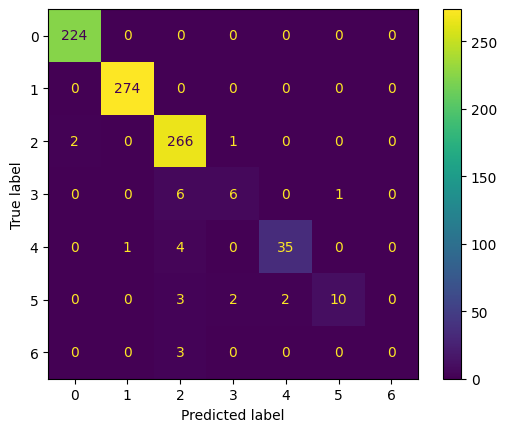

In [110]:
# confusion matrix
from sklearn import metrics

actual = df_test["class"]
predicted = df_test["pred_class"]

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1 , 2, 3, 4, 5, 6])

cm_display.plot()
plt.show()

In [111]:
num_correct = 0
num_incorrect = 0

for i in range(df_test.shape[0]):
  if int(df_test["class"][i]) == int(df_test["pred_class"][i]):
    num_correct += 1
  else:
    num_incorrect += 1

print("accuracy = " + str(num_correct/(num_correct + num_incorrect)))

accuracy = 0.9702380952380952


In [112]:
# split into dataframes for each cluster

clusters = np.unique(np.array(feats_df["class"])) # list of unique clusters
print(np.unique(np.array(df_test["pred_class"]), return_counts = True)) 

cluster_dfs = [] # list of dfs for each cluster

for i in clusters:
  df = df_test[df_test["pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  cluster_dfs.append(df)

# print sizes of each pred_cluster
class_num = 0
for df in cluster_dfs:
  print(str(class_num) + ": " + str(df.shape[0]))
  class_num += 1

(array([0, 1, 2, 3, 4, 5]), array([226, 275, 282,   9,  37,  11]))
0: 226
1: 275
2: 282
3: 9
4: 37
5: 11
6: 0


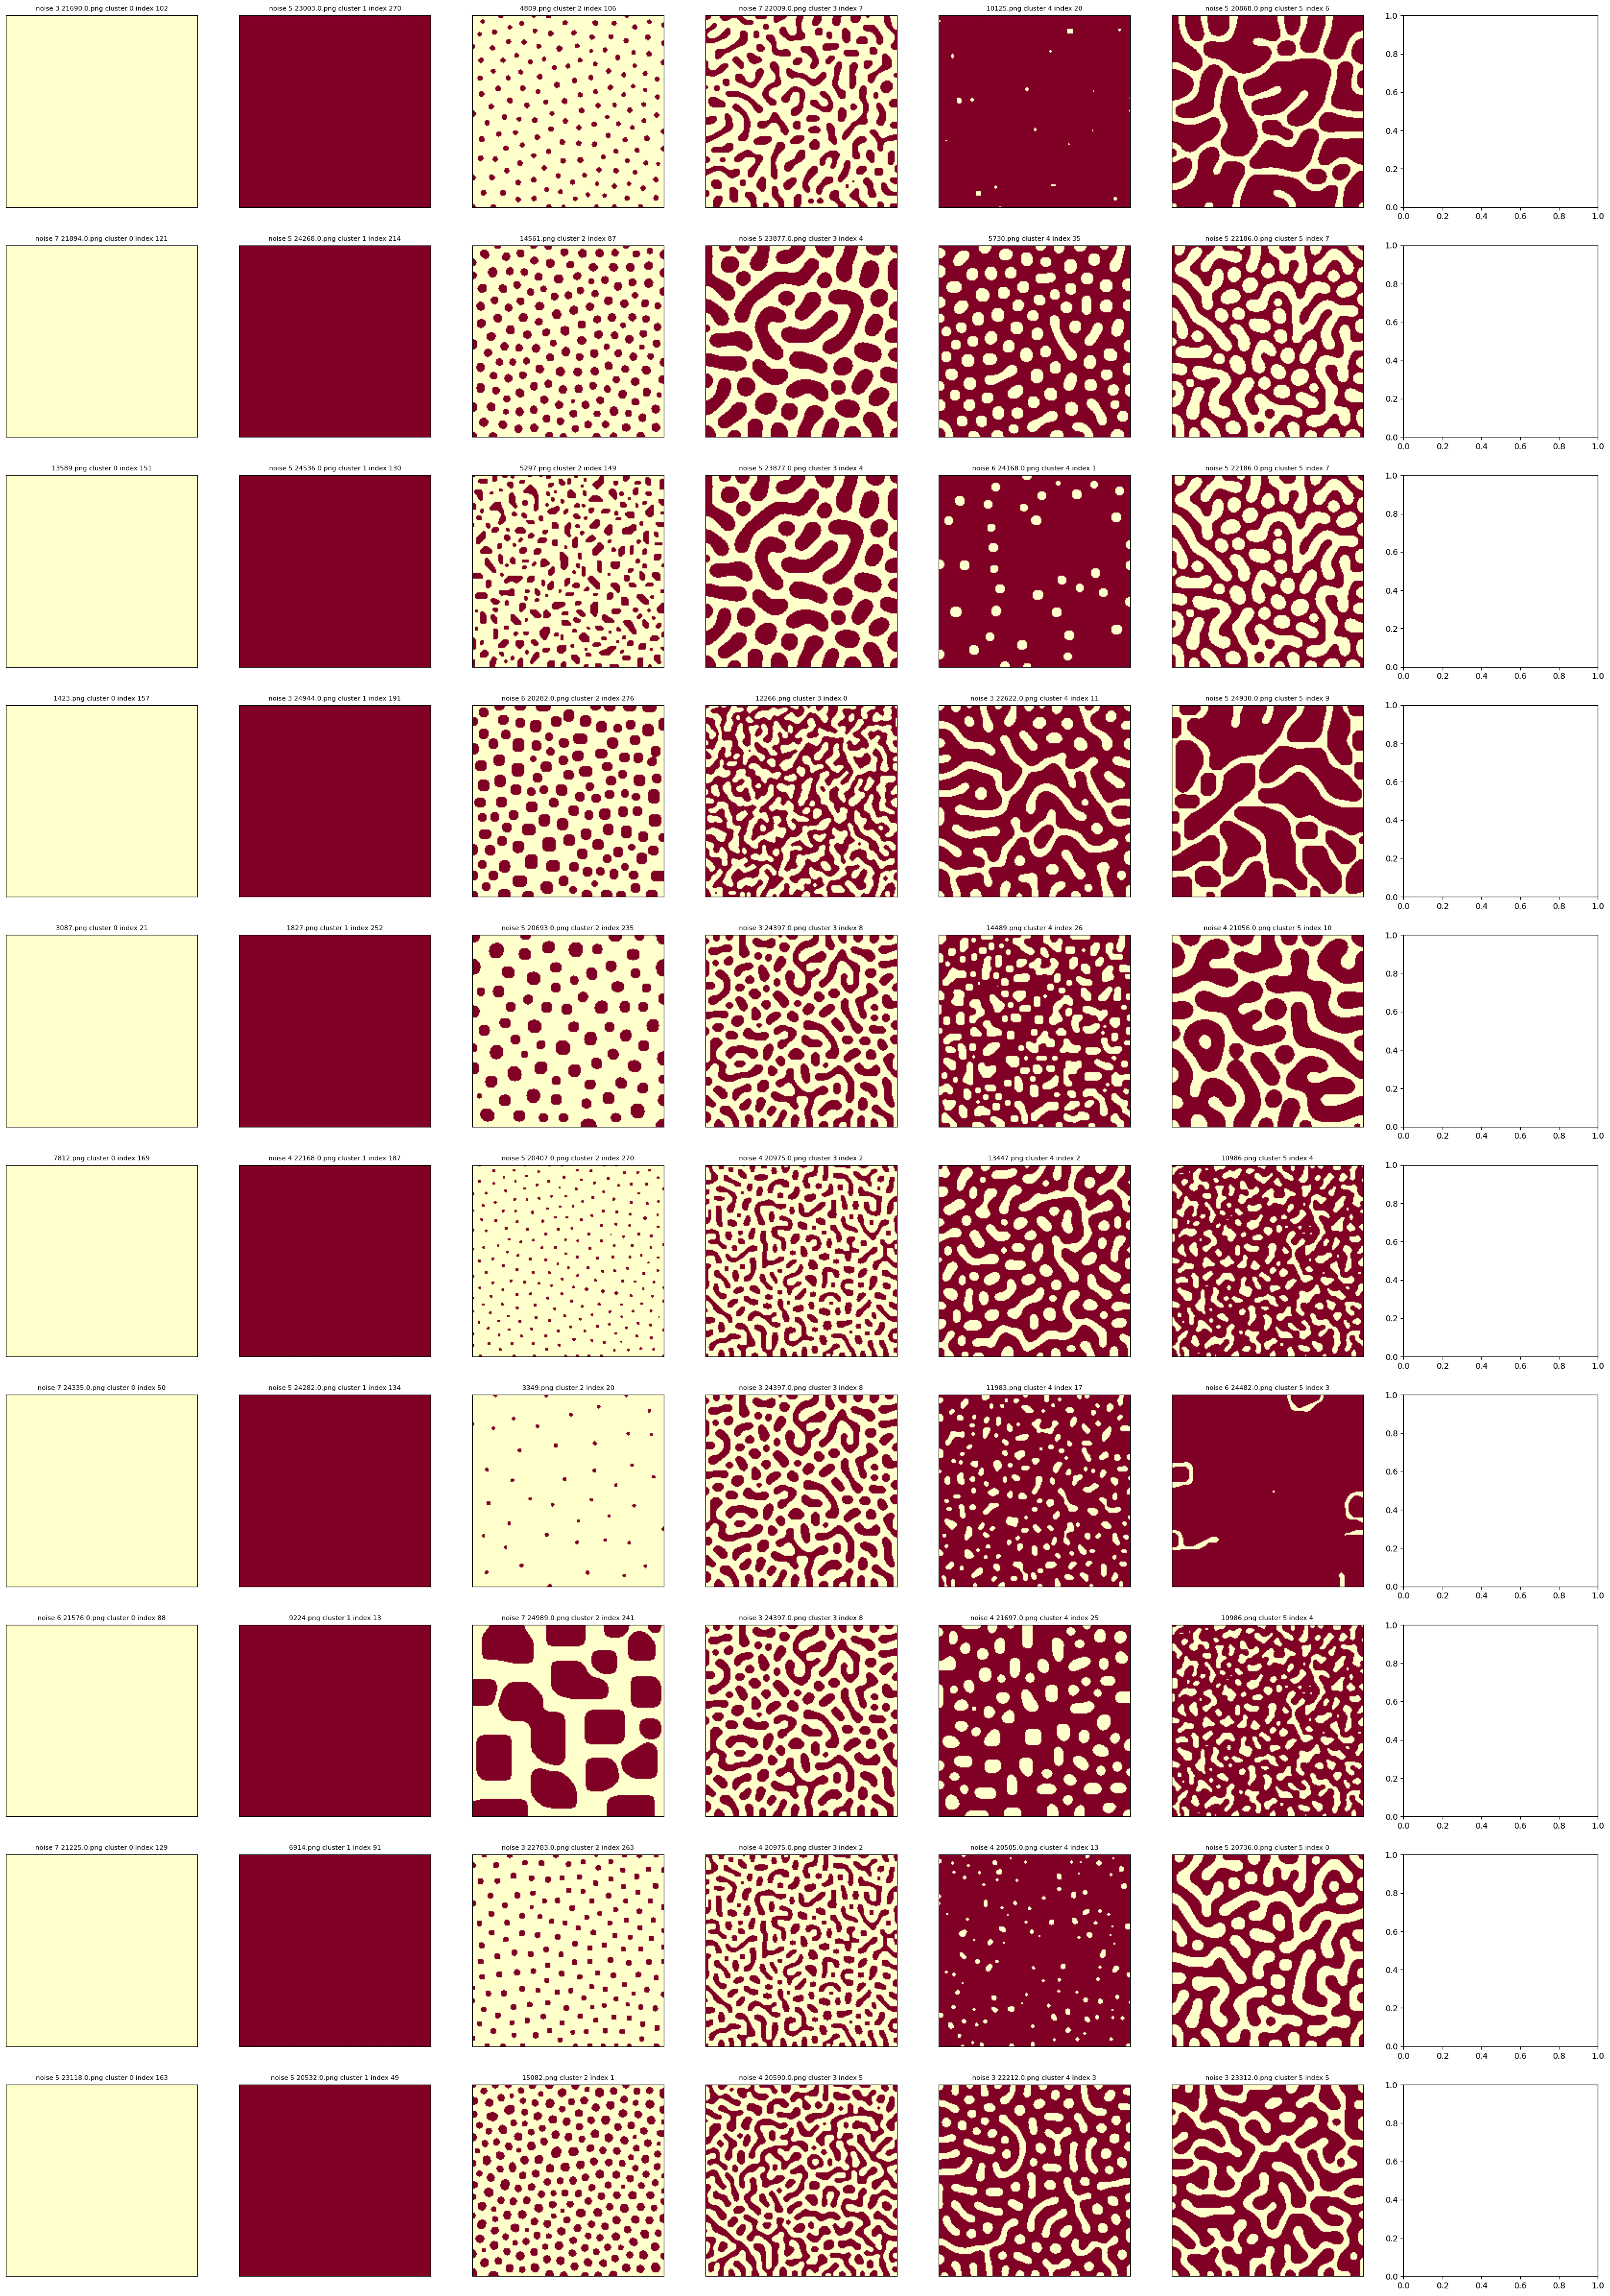

In [113]:
# visualize images from each predicted class:

# print out random images from clusters

num_imgs = 10

fig, ax = plt.subplots(num_imgs, len(cluster_dfs))

for i in range(num_imgs):
  for j in range(len(cluster_dfs)):
    df = cluster_dfs[j]
    if df.shape[0] == 0:
      continue
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    image_path = df["dir"][num] + df["path"][num]
    img = np.array(Image.open(image_path))
    ax[i][j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][j].set_title(df["path"][num] + " cluster " + str(j) + " index " + str(num), fontsize = 8)
    ax[i][j].get_xaxis().set_visible(False)
    ax[i][j].get_yaxis().set_visible(False)


fig.set_figwidth(5*len(cluster_dfs))
fig.set_figheight(5 * num_imgs)
plt.show()

In [114]:

# extract features from the rest of the unclassified images

# Load the pretrained model
pred_model = models.resnet50(pretrained=False)
num_ftrs = pred_model.fc.in_features
pred_model.fc = nn.Linear(num_ftrs, 7)
#pred_model.cuda()

pred_model.load_state_dict(torch.load("content/best_classification_model_train_840.pth"))

/Users/reeshapatel/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/reeshapatel/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

In [135]:
# use feats df

# list of 39517 random indices
with open("data/random_indices_array.pkl", 'rb') as f:
  list_range = pickle.load(f) # deserialize using load()
# as of 8-15-14, currently through [0:7307]

# full dataframe with 39517 images, only 5 columns: class, noise, seed, path, dir
with open("data/2024-08-11_manual_classification_updated_image_dir.pkl", 'rb') as f:
  feats_df = pickle.load(f) # deserialize using load()

feats_df_notnone = feats_df[feats_df["class"] != "None"]
print(feats_df_notnone.shape)
feats_df_notnone["class"].value_counts()

(26276, 5)


class
2    12585
1    10707
3     2330
5      329
6      165
4      122
7       35
         3
Name: count, dtype: int64

In [ ]:
# remove rows that have already been classified
feats_df = feats_df.drop(list_range[0:7307], axis = "rows")

feats_df.reset_index(inplace = True, drop = True)
print(feats_df.shape)

(32210, 5)


In [137]:
df_clustering = feats_df

# From ChatGPT
# This list will store the features
features = []

def hook(module, input, output):
    features.append(output)

# Register the hook to the final pooling layer
# final_bn = pred_model.layer4[-1].bn3
pred_model.avgpool.register_forward_hook(hook)
# final_bn.register_forward_hook(hook)

pred_model.eval()

counter = 0
# # Load an image
for i in range(df_clustering.shape[0]):
# for i in range(1):
  img_path = df_clustering["dir"][i] + df_clustering["path"][i]
  img = Image.open(img_path)
  img_transformed = data_transforms(img, "val")

  # Pass the image through the model
  with torch.no_grad():
      _ = pred_model(img_transformed.unsqueeze(0))

  if counter % 500 == 0:
    print(counter)

  counter += 1

  # # The features are stored in the list
  # features = features[0]

  # # Flatten the output tensor if needed
  # features = features.view(features.size(0), -1)

  # print(features.shape)

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
10500
11000
11500
12000
12500
13000
13500
14000
14500
15000
15500
16000
16500
17000
17500
18000
18500
19000
19500
20000
20500
21000
21500
22000
22500
23000
23500
24000
24500
25000
25500
26000
26500
27000
27500
28000
28500
29000
29500
30000
30500
31000
31500
32000


In [138]:
# save features in a numpy array

feat_array = np.empty((df_clustering.shape[0], 2048))

for i in range(df_clustering.shape[0]):
  feats = np.array(features[i].cpu()).reshape(2048)
  feat_array[i,:] = feats

print(feat_array.shape)

feat_array

(32210, 2048)


array([[0.64443684, 0.37838194, 0.29332528, ..., 0.0457358 , 0.25235775,
        0.22677492],
       [0.64443684, 0.37838194, 0.29332528, ..., 0.0457358 , 0.25235775,
        0.22677492],
       [0.02583369, 1.20777774, 0.27345514, ..., 0.4224799 , 0.27074194,
        1.15933895],
       ...,
       [0.00215911, 1.21862495, 0.11195879, ..., 0.78375727, 0.18383917,
        0.92430353],
       [0.64443684, 0.37838194, 0.29332528, ..., 0.0457358 , 0.25235775,
        0.22677492],
       [0.64443684, 0.37838194, 0.29332528, ..., 0.0457358 , 0.25235775,
        0.22677492]])

In [ ]:
pickle_out = open("data/2024-08-19_feat_array_unscaled.pkl","wb")
pickle.dump(feat_array, pickle_out)
pickle_out.close()

with open("data/2024-08-19_feat_array_unscaled.pkl", 'rb') as f:
  feat_array = pickle.load(f) # deserialize using load()


# not used at all since df_classes is reassigned to feats_df which is manually classified data 
# first PCA is 5 components; uses clusters defined from KMeans clustering
# second PCA is 2 components; uses predicted classes from trained model

# with open("data/2024-08-18_curr_df.pkl", 'rb') as f:
#   df_classes = pickle.load(f) # deserialize using load() 

# df_classes.shape

(32210, 8)

In [ ]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

feat_array_scaled = sc.fit_transform(feat_array)

print(feat_array_scaled.shape)


# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components = 5)


pca_data = pca.fit_transform(feat_array_scaled)
print(pca_data.shape)


explained_variance = pca.explained_variance_ratio_

print(explained_variance)

(32210, 2048)
(32210, 5)
[0.26982979 0.20582652 0.1003371  0.07394449 0.04029907]


python(83242) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


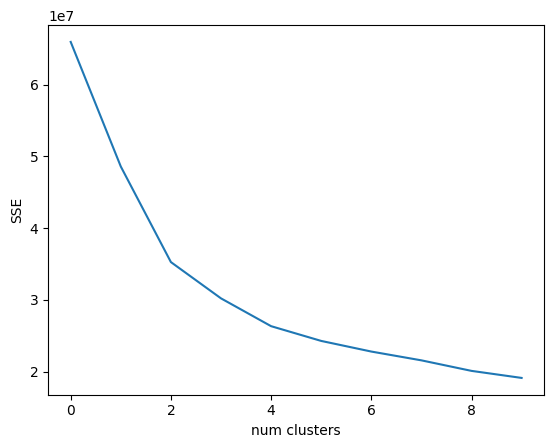

In [142]:
# K_means clustering
from sklearn.cluster import KMeans

#Find optimum number of clusters
sse = [] #SUM OF SQUARED ERROR
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(feat_array_scaled)
    sse.append(km.inertia_)

fig, ax = plt.subplots()
ax.set(xlabel = "num clusters", ylabel = "SSE")

ax.plot(sse)

In [151]:
# K_means clustering
# from sklearn.cluster import KMeans
num_clusters = 7
km = KMeans(n_clusters = num_clusters, init='k-means++', n_init=50, max_iter=300,
            tol=0.0001, random_state=42)

clusters = km.fit(feat_array)

In [152]:
# clusters

df_clustering["cluster"] = clusters.labels_
df_clustering["pc1"] = pca_data[:,0]
df_clustering["pc2"] = pca_data[:,1]

In [158]:
num_clusters = 7
clusters = np.arange(0,num_clusters)# list of unique clusters

cluster_dfs = [] # list of dfs for each cluster

for i in clusters:
  df = df_clustering[df_clustering["cluster"] == i]
  df.reset_index(inplace = True, drop = True)
  cluster_dfs.append(df)



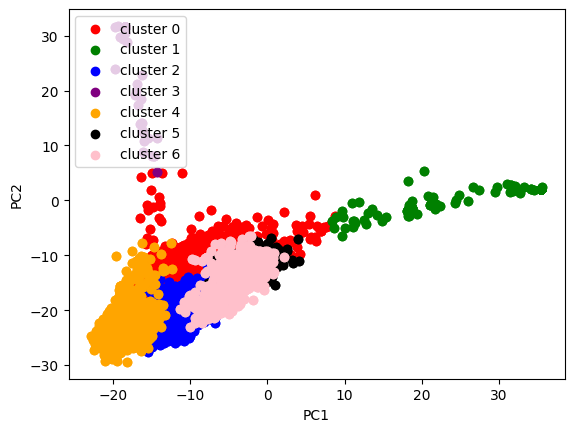

In [ ]:
# plot the data

fig, ax = plt.subplots()

colors = ["red","green","blue","purple","orange","black","pink"]

for j in clusters:
  df = cluster_dfs[j] 
  ax.scatter(df["pc1"], df["pc2"], c = colors[j], label = "cluster " + str(j))


leg = ax.legend(loc="upper left")

ax.set(xlabel = "PC1", ylabel = "PC2")
plt.show()



In [164]:
counter = 0
for cluster in cluster_dfs:
  print("cluster " + str(counter) + ": " + str(cluster.shape[0]))
  counter += 1

cluster 0: 5040
cluster 1: 9654
cluster 2: 2208
cluster 3: 8032
cluster 4: 5186
cluster 5: 980
cluster 6: 1110


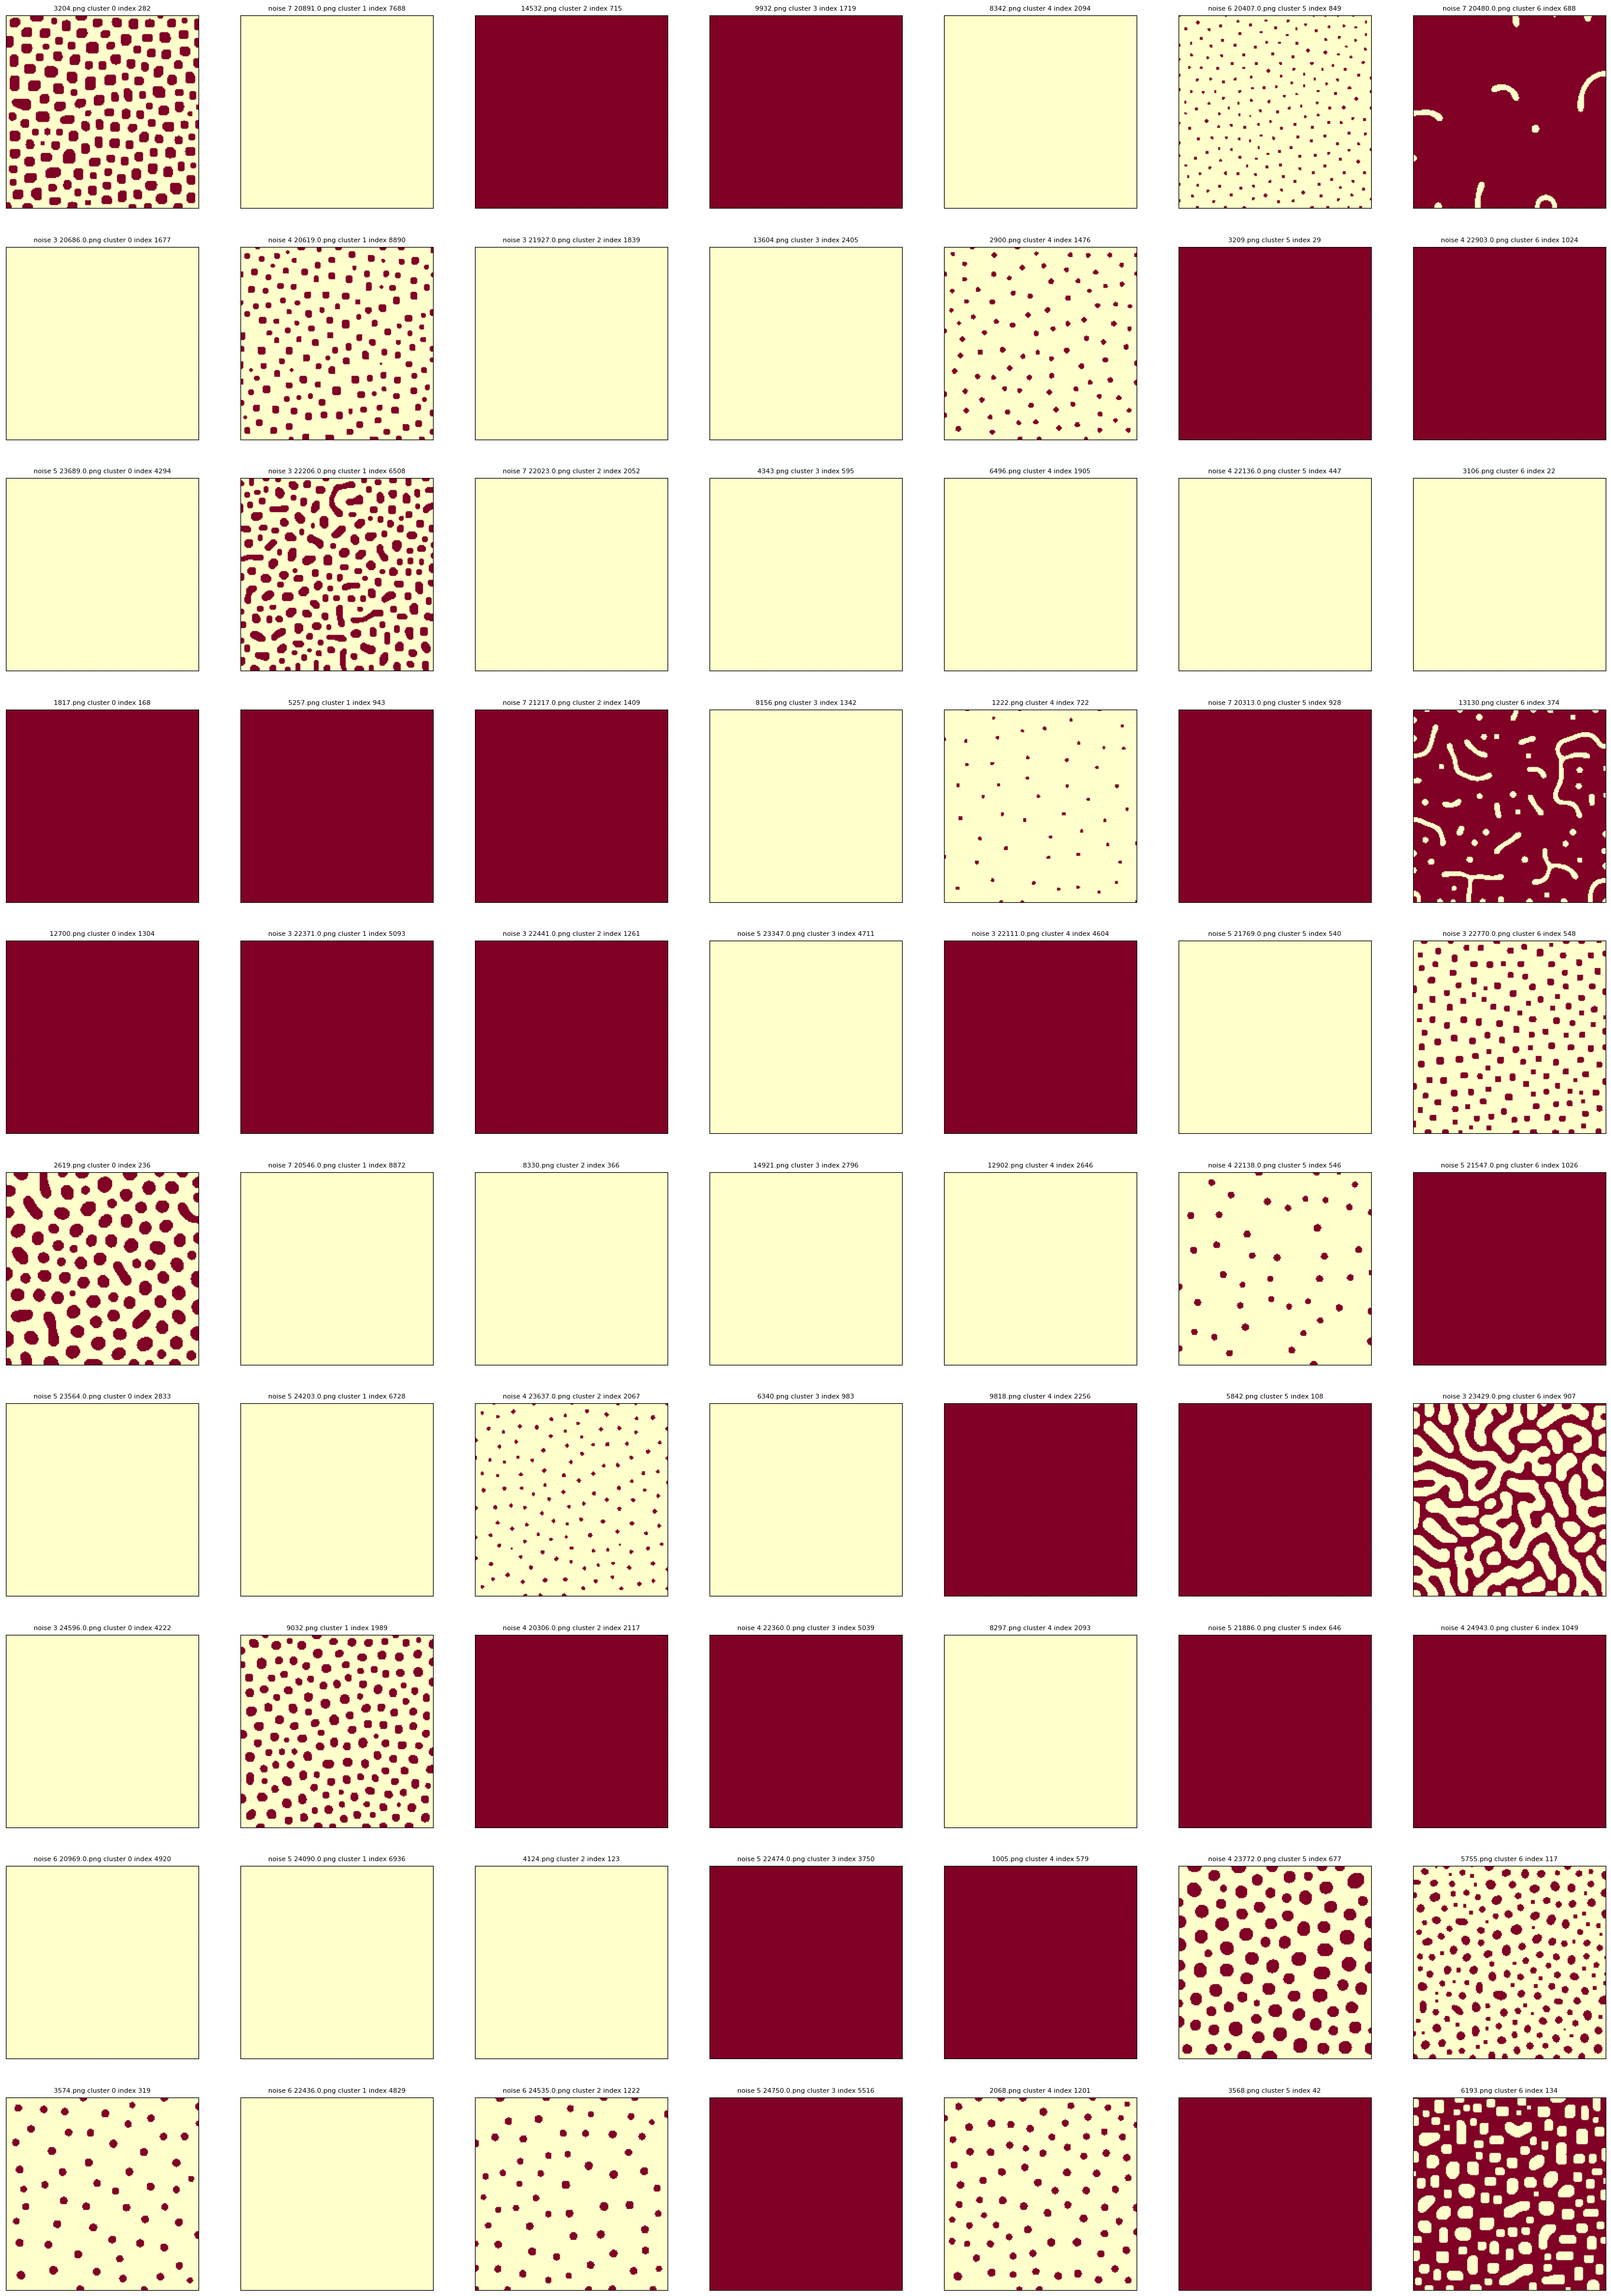

In [165]:
# print out random images from clusters

num_imgs = 10

fig, ax = plt.subplots(num_imgs, len(cluster_dfs))

for i in range(num_imgs):
  for j in range(len(cluster_dfs)):
    df = cluster_dfs[j]
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    image_path = df["dir"][num] + df["path"][num]
    img = np.array(Image.open(image_path))
    ax[i][j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][j].set_title(df["path"][num] + " cluster " + str(j) + " index " + str(num), fontsize = 8)
    ax[i][j].get_xaxis().set_visible(False)
    ax[i][j].get_yaxis().set_visible(False)


fig.set_figwidth(5*len(cluster_dfs))
fig.set_figheight(5 * num_imgs)
plt.show()

In [166]:
#initialize new model with same architecture as the one that was trained
pred_model = models.resnet50(pretrained=False)
num_ftrs = pred_model.fc.in_features
pred_model.fc = nn.Linear(num_ftrs, 7)
#pred_model.cuda()

#apply saved weights to the model
pred_model.load_state_dict(torch.load("content/best_classification_model_train_840.pth"))

#set model mode to eval
pred_model.eval()

/Users/reeshapatel/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/reeshapatel/miniconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [167]:
df_classes = feats_df

def data_transforms(image, mode):
  if mode == "train":
    tnsfrm = transforms.Compose([
            # transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor()
        ])
  elif mode == "val":
    tnsfrm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224,224))
    ])

  img = tnsfrm(image)
  img = torch.cat((img,img,img),0)
  return img

#choose image

#make predictions on the image
preds = []
counter = 0

with torch.no_grad():
  for i in range(df_classes.shape[0]):
    image_path = df_classes["dir"][i] + df_classes["path"][i]
    pred_image = np.array(Image.open(image_path))
    pred_img_transformed = data_transforms(pred_image,"val")
    preds.append((pred_model(pred_img_transformed.unsqueeze(0))))

    if counter % 500 == 0:
      print(counter)

    counter += 1


0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000
7500
8000
8500
9000
9500
10000
10500
11000
11500
12000
12500
13000
13500
14000
14500
15000
15500
16000
16500
17000
17500
18000
18500
19000
19500
20000
20500
21000
21500
22000
22500
23000
23500
24000
24500
25000
25500
26000
26500
27000
27500
28000
28500
29000
29500
30000
30500
31000
31500
32000


In [168]:
# add preds to df
pred_class = []

for i in preds:
  p = i.cpu()
  argmax = np.argmax(p)
  pred_class.append(int(argmax))


df_classes["pred_class"] = pred_class

In [169]:
np.unique(np.array(df_classes["pred_class"]))

array([0, 1, 2, 3, 4, 5])

In [ ]:
# PCA on feat arrays

# scaling data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

feat_array_scaled = sc.fit_transform(feat_array)

print(feat_array_scaled.shape)


# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca_data = pca.fit_transform(feat_array_scaled)


explained_variance = pca.explained_variance_ratio_

print(explained_variance)

df_classes["pc1"] = pca_data[:,0]
df_classes["pc2"] = pca_data[:,1]

(32210, 2048)
[0.26982979 0.20582652]


In [171]:
df_classes[df_classes["pred_class"] == 3]

,class,noise,path,seed,dir,cluster,pc1,pc2,pred_class
1140,None,2,1375.png,1375,content/Images3/,4,-16.577618,-22.511606,3
1270,None,2,1537.png,1537,content/Images3/,4,-17.456741,-21.775976,3
1416,None,2,1724.png,1724,content/Images3/,4,-17.834314,-22.527401,3
1550,None,2,1884.png,1884,content/Images3/,4,-21.703176,-24.956111,3
1588,None,2,1929.png,1929,content/Images3/,4,-19.769450,-25.673555,3
...,...,...,...,...,...,...,...,...,...
31618,None,4,noise 4 22346.0.png,22346.0,content/Images1/,3,-18.437016,31.618519,3
31902,None,7,noise 7 20248.0.png,20248.0,content/Images1/,2,-8.914214,-20.672176,3
31998,None,4,noise 4 23764.0.png,23764.0,content/Images1/,6,-2.125121,-12.712372,3
32013,None,6,noise 6 24081.0.png,24081.0,content/Images1/,1,35.470375,2.098211,3


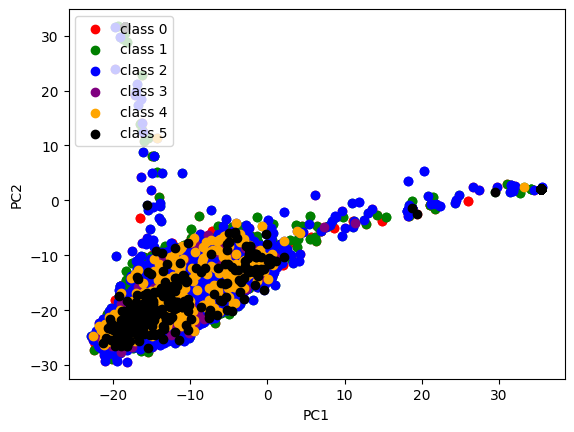

In [172]:
# plot the model predicted class in feature space


num_classes = 6
classes = np.arange(0,num_classes)# list of unique clusters

class_dfs = [] # list of dfs for each cluster

for i in classes:
  df = df_classes[df_classes["pred_class"] == i]
  df.reset_index(inplace = True, drop = True)
  class_dfs.append(df)


fig, ax = plt.subplots()

colors = ["red","green","blue","purple","orange","black","pink"]
alpha = [1,1,1,1,1,1,0]
for j in classes:
  df = class_dfs[j]
  ax.scatter(df["pc1"], df["pc2"], c = colors[j], label = "class " + str(j), alpha = alpha[j])


leg = ax.legend(loc="upper left")

ax.set(xlabel = "PC1", ylabel = "PC2")
plt.show()



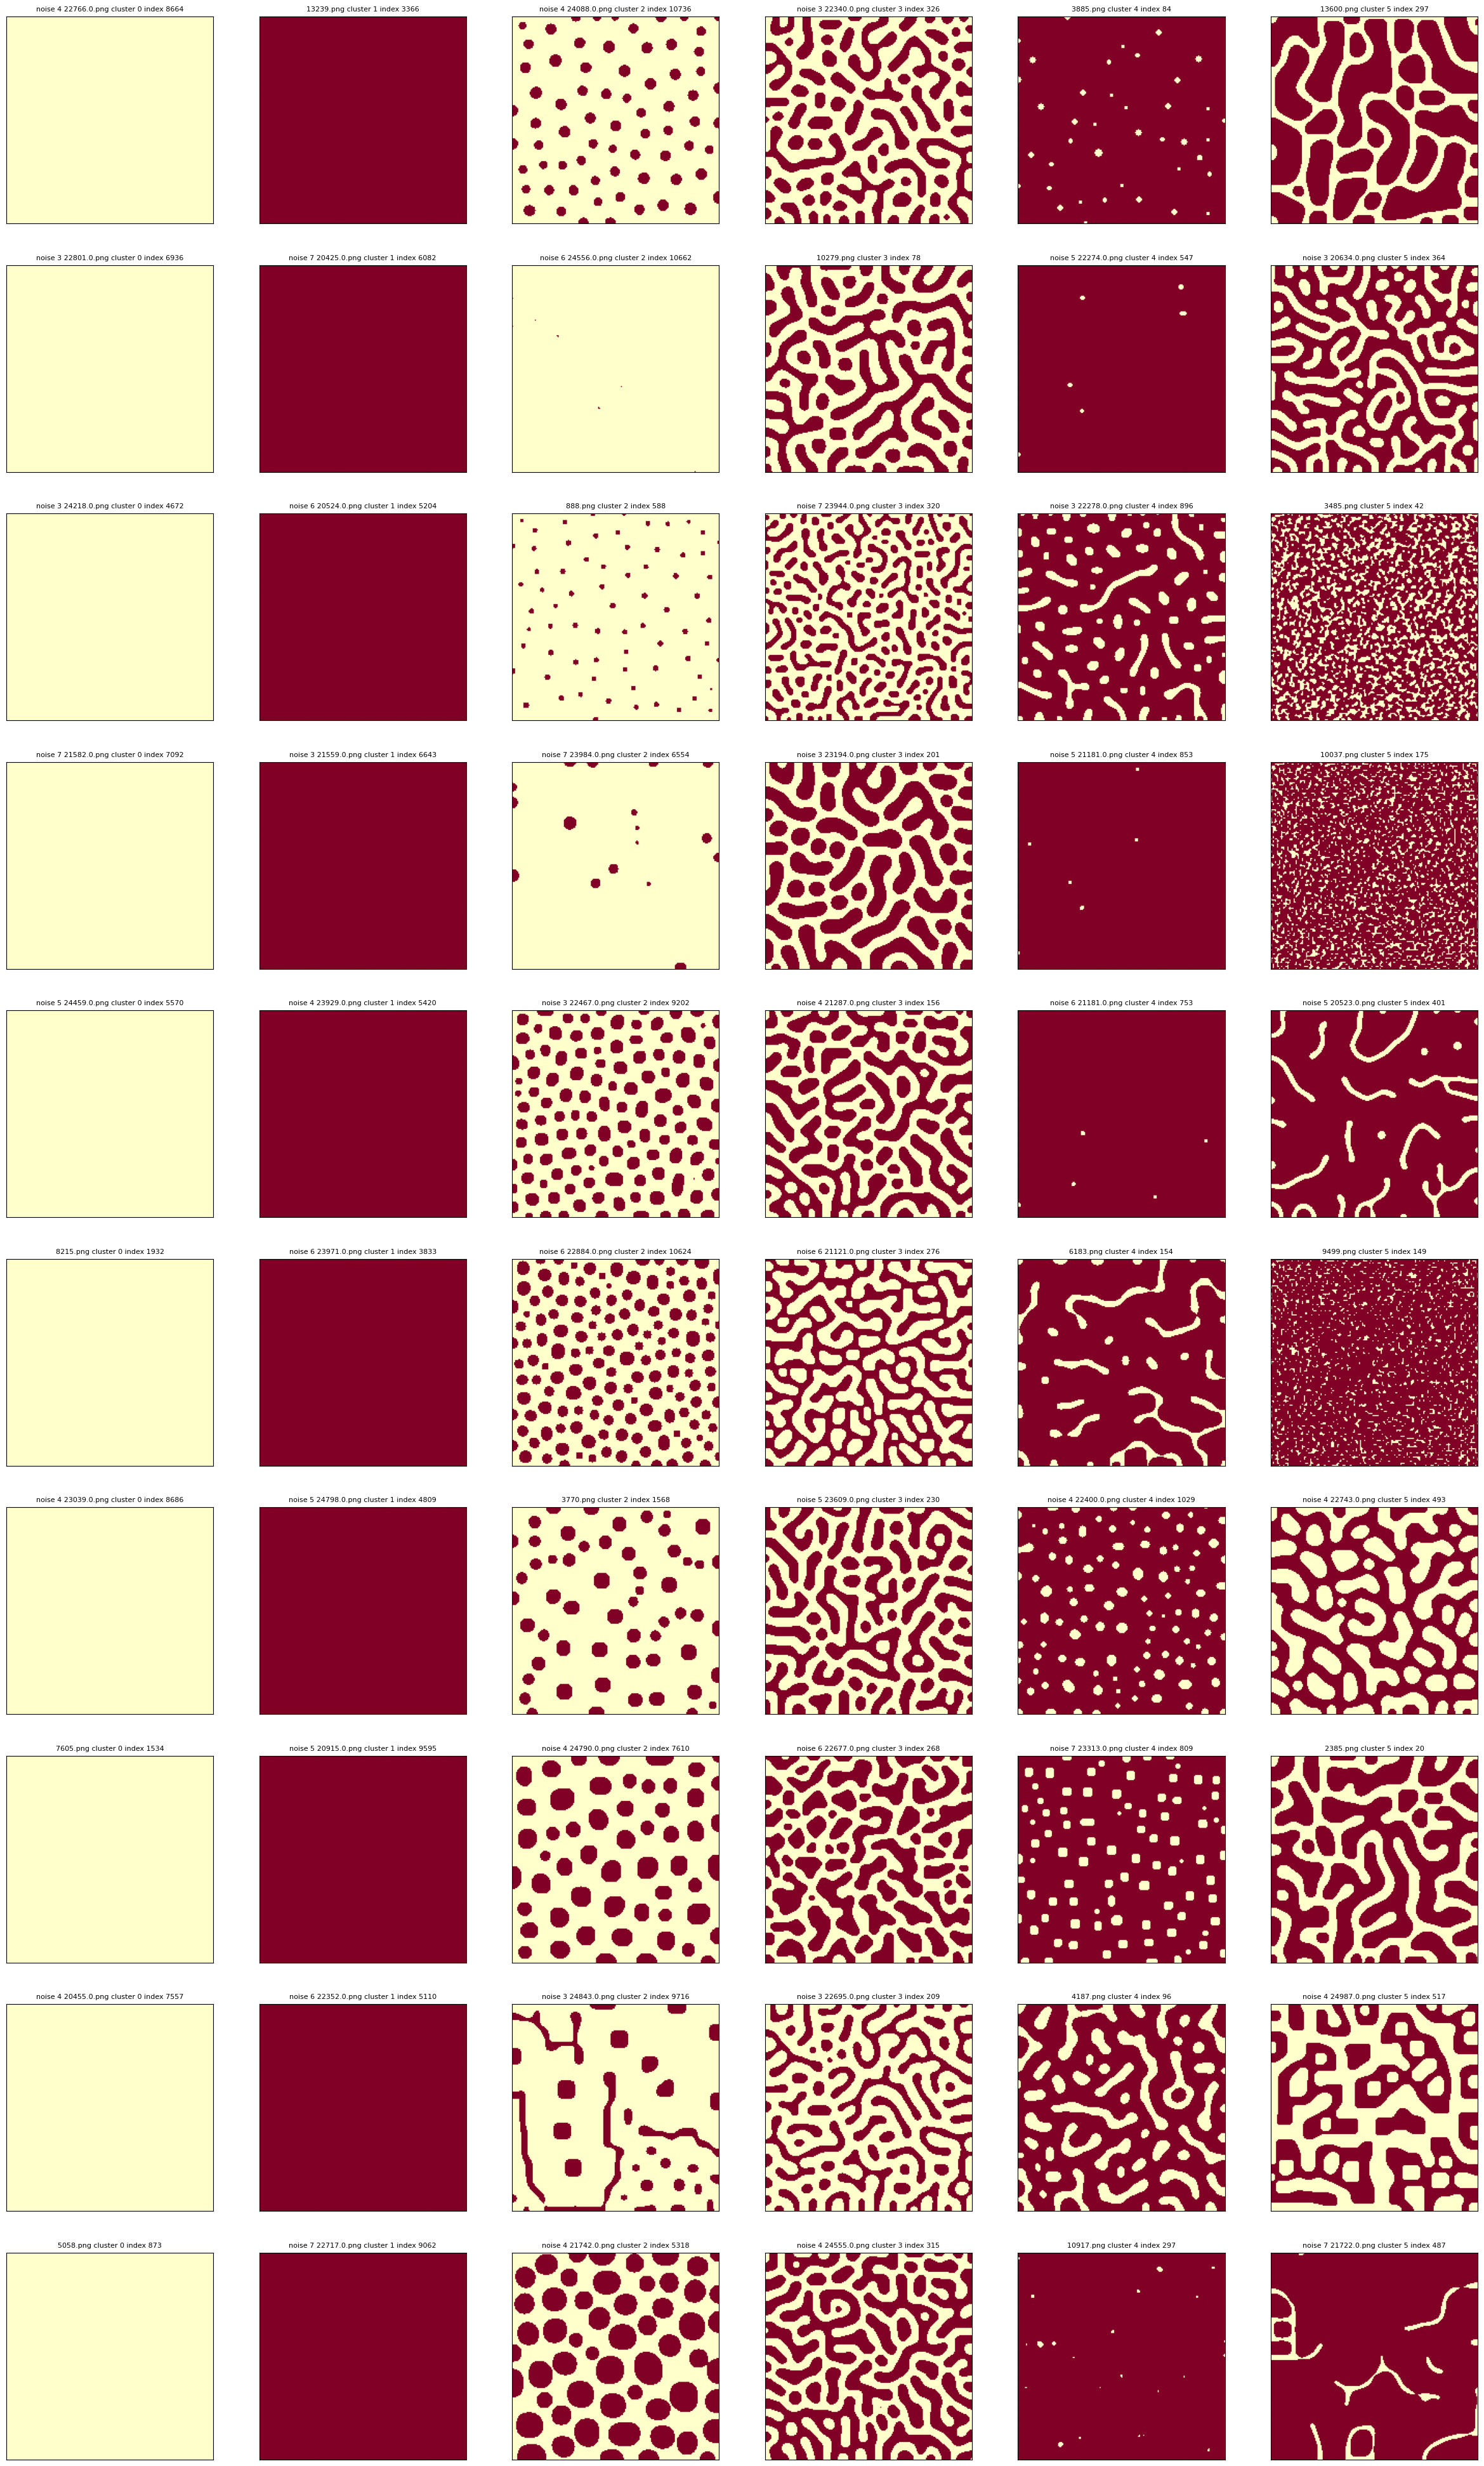

In [174]:
# print out random images from clusters

num_imgs = 10

fig, ax = plt.subplots(num_imgs, len(class_dfs))

for i in range(num_imgs):
  for j in range(len(class_dfs)):
    df = class_dfs[j]
    num = np.random.randint(low = 0, high= df.shape[0], size=1, dtype=int)[0]
    image_path = df["dir"][num] + df["path"][num]
    img = np.array(Image.open(image_path))
    ax[i][j].imshow(img, cmap = "YlOrRd", vmin = 0, vmax = 255)
    ax[i][j].set_title(df["path"][num] + " cluster " + str(j) + " index " + str(num), fontsize = 8)
    ax[i][j].get_xaxis().set_visible(False)
    ax[i][j].get_yaxis().set_visible(False)


fig.set_figwidth(5*len(class_dfs))
fig.set_figheight(5 * num_imgs)
plt.show()

In [ ]:
# pickle_out = open("/content/drive/MyDrive/2024_Summer_Work_(Shared_Drive_Is_Full)/2024-08-18_curr_df.pkl","wb")
# pickle.dump(df_classes, pickle_out)
# pickle_out.close()

In [175]:
counter = 0
for cluster in class_dfs:
  print("cluster " + str(counter) + ": " + str(cluster.shape[0]))
  counter += 1

cluster 0: 8750
cluster 1: 10392
cluster 2: 11009
cluster 3: 333
cluster 4: 1055
cluster 5: 671
